# Aula 10: Treinando seu Próprio Detector YOLOv8 🚀

Bem-vindo à prática da Aula 10! Neste notebook, vamos:
1.  Preparar nosso dataset.
2.  Treinar um modelo YOLOv8 do zero (usando Transfer Learning).
3.  **Analisar os Gráficos** de aprendizado (Loss, Precisão).
4.  Testar o modelo treinado.

## 1. Configuração Inicial
Vamos importar a biblioteca e garantir que tudo está instalado.

In [1]:
import os
import shutil
import torch
from ultralytics import YOLO, settings
from IPython.display import Image, display

# 1. Configurar pasta de saída local para o projeto
# Isso garante que a pasta 'runs' será criada na raiz do seu repositório clonado
pasta_do_notebook = os.getcwd()
raiz_do_projeto = os.path.dirname(pasta_do_notebook)
pasta_runs = os.path.join(raiz_do_projeto, 'runs')

settings.update({'runs_dir': pasta_runs})

# 2. Verificar hardware disponível
print("--- Verificação de Hardware ---")
if torch.cuda.is_available():
    print(f"✅ CUDA (GPU) disponível: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ CUDA não encontrada. O código rodará na CPU (mais lento).")
print("-------------------------------\n")

print(f"📂 Os resultados do YOLO serão salvos em: {pasta_runs}")

--- Verificação de Hardware ---
✅ CUDA (GPU) disponível: NVIDIA GeForce GTX 1660 Ti
-------------------------------

📂 Os resultados do YOLO serão salvos em: /home/joaov/github/neymar-roboflow/runs


## 2. Preparando o Dataset
Se você baixou um dataset do Roboflow (ZIP), extraia ele na pasta do projeto.
Certifique-se de que o arquivo `data.yaml` está correto.

**Exemplo:** Se baixou o 'Aquarium', garanta que a pasta se chama `dataset_aquarium`.

In [2]:
# Defina aqui o caminho para o SEU arquivo data.yaml
# Opções comuns: 'dataset_aquarium/data.yaml' ou 'dataset_construction/data.yaml'

dataset_path = '../dataset_aquarium/data.yaml'  # <--- EDITE AQUI se estiver usando outro

if not os.path.exists(dataset_path):
    print(f"⚠️ ATENÇÃO: Arquivo '{dataset_path}' não encontrado. Verifique o caminho!")
else:
    print(f"✅ Dataset encontrado: {dataset_path}")

⚠️ ATENÇÃO: Arquivo '../dataset_aquarium/data.yaml' não encontrado. Verifique o caminho!


## 3. O Treinamento (Training) 🔥
Aqui a mágica acontece. Vamos usar o modelo `yolov8n.pt` (Nano) como base.

*   `data`: Onde estão as imagens.
*   `epochs`: Quantas vezes o modelo vai estudar todo o dataset. (Recomendado: 50+, para teste use 5).
*   `imgsz`: Tamanho da imagem (640 é padrão).

In [4]:
import os
from ultralytics import YOLO

# 1. Descobrir a raiz do projeto (subindo um nível a partir da pasta /notebooks)
pasta_do_notebook = os.getcwd()
raiz_do_projeto = os.path.dirname(pasta_do_notebook)

# 2. Configurar o caminho REAL para o seu dataset do Neymar
dataset_path = os.path.join(
    raiz_do_projeto, 
    "dataset-ney", 
    "neymar.v1i.yolov8", 
    "data.yaml"
)

# 3. Carregar o modelo pré-treinado
model = YOLO('yolov8n.pt')

# 4. Iniciar o treinamento leve
# Os resultados serão salvos em runs/detect/trainX conforme configurado antes
results = model.train(data=dataset_path, epochs=5, imgsz=416, batch=2)

New https://pypi.org/project/ultralytics/8.4.52 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.51 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/joaov/github/neymar-roboflow/dataset-ney/neymar.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov

## 4. Analisando os Gráficos 📊
O grande diferencial de usar Notebooks! O YOLO gera automaticamente gráficos de performance.

Vamos visualizar o `results.png` que contém:
*   **Box_loss**: Erro na posição da caixa (quanto menor, melhor).
*   **Cls_loss**: Erro na classificação (disse que era gato mas era cachorro).
*   **mAP50**: Precisão geral (quanto maior, melhor).

Resultados salvos em: /home/joaov/github/neymar-roboflow/notebooks/runs/detect/train-8


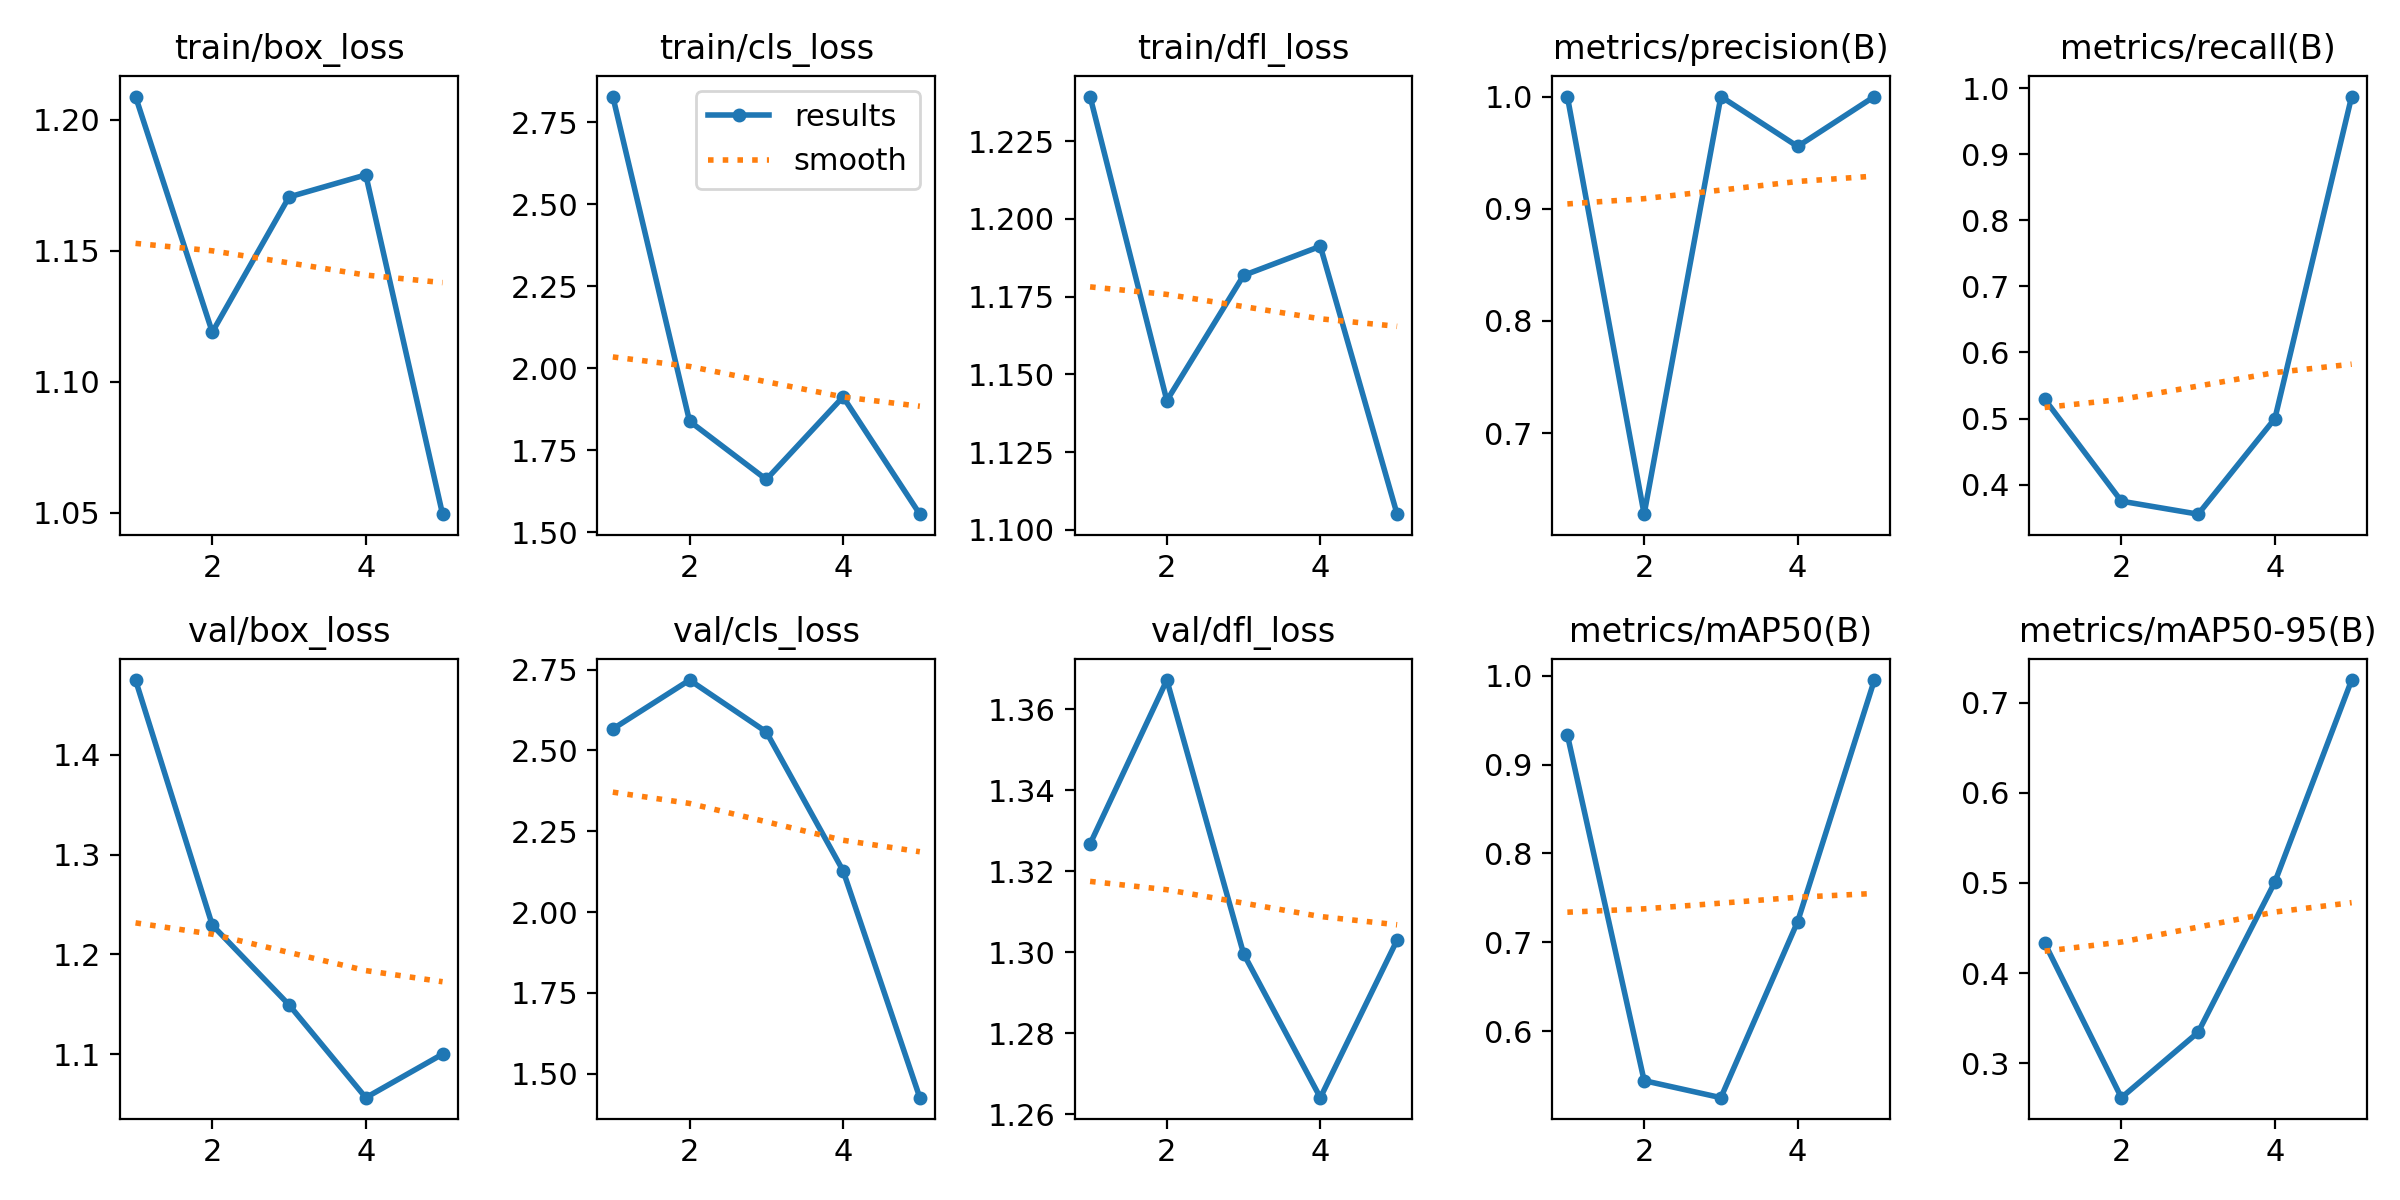

In [5]:
# O objeto 'results' guarda o diretório onde tudo foi salvo
print(f"Resultados salvos em: {results.save_dir}")

# Exibir os gráficos de perda e performance
Image(filename=f'{results.save_dir}/results.png')

### 🧐 Entendendo o Gráfico `results.png`

Essas curvas coloridas são o eletrocardiograma do seu modelo. Aqui está como ler:

#### 📏 O que os eixos X e Y medem?

*   **Eixo X (Horizontal):** Representa o **TEMPO** ou **ÉPOCAS**.
    Cada número (1, 2, 5, 10...) é uma "rodada" completa de estudos que o modelo fez. Se o gráfico vai até 10, significa que o modelo leu o dataset inteiro 10 vezes.
*   **Eixo Y (Vertical):** Representa o **VALOR** que está sendo medido no título do gráfico.
    *   Se for um gráfico de **LOSS (Perda)**: O eixo Y é o tamanho do **ERRO**. Quanto mais alto, mais o modelo está errando. Queremos que essa linha desça.
    *   Se for um gráfico de **MÉTRICA (Precision, Recall, mAP)**: O eixo Y é a **NOTA** (de 0.0 a 1.0). Quanto mais alto, melhor.

#### 1. Os Erros (Loss) - Quanto menor, melhor 📉
Imagine que o modelo é um aluno fazendo uma prova.
*   **Box Loss (Erro de Caixa):** O aluno desenhou o quadrado no lugar certo? Se a caixa ficou torta ou do tamanho errado, esse erro sobe.
*   **Cls Loss (Erro de Classificação):** O aluno acertou o nome do objeto? Se ele viu um Tubarão e escreveu "Peixe", esse erro sobe.
*   **DFL Loss:** É um ajuste fino da borda da caixa. Não se preocupe muito com ele agora.

**Train vs Val:**
*   **train (Treino):** O aluno estudando em casa.
*   **val (Validação):** O aluno fazendo o simulado.
*   ⚠️ **PERIGO:** Se o erro de `train` cair mas o de `val` subir, o aluno está **decorando** as questões (Overfitting) e vai ir mal na prova real!

#### 2. As Notas (Métricas) - Quanto maior, melhor 📈
Aqui avaliamos a qualidade do "Detetive IA".

*   **Precision (Precisão):** O detetive é cuidadoso? 
    *   *"De todos os suspeitos que eu prendi, quantos eram realmente culpados?"*
    *   Alta Precisão = Poucos alarmes falsos.
*   **Recall (Revocação):** O detetive é atento?
    *   *"De todos os bandidos que existem na cidade, quantos eu consegui capturar?"*
    *   Alto Recall = Deixa passar pouca coisa.
*   **mAP50 (Mean Average Precision):** A nota geral.
    *   É como um professor bonzinho que aceita se você desenhar a caixa cobrindo pelo menos 50% do objeto.
*   **mAP50-95:** A nota rigorosa.
    *   É a média das notas exigindo caixas perfeitas (de 50% até 95% de sobreposição).

## 5. Matriz de Confusão 😵
A Matriz de Confusão é um mapa dos erros.
*   **Eixo Vertical (True):** O que a imagem REALMENTE é.
*   **Eixo Horizontal (Predicted):** O que o modelo ACHOU que era.

**Como ler:**
*   A **Linha Diagonal** principal mostra os acertos (Ex: Era Tubarão e ele disse Tubarão).
*   Tudo fora da diagonal é confusão! (Ex: Era Peixe, mas ele achou que era o fundo da imagem "background").

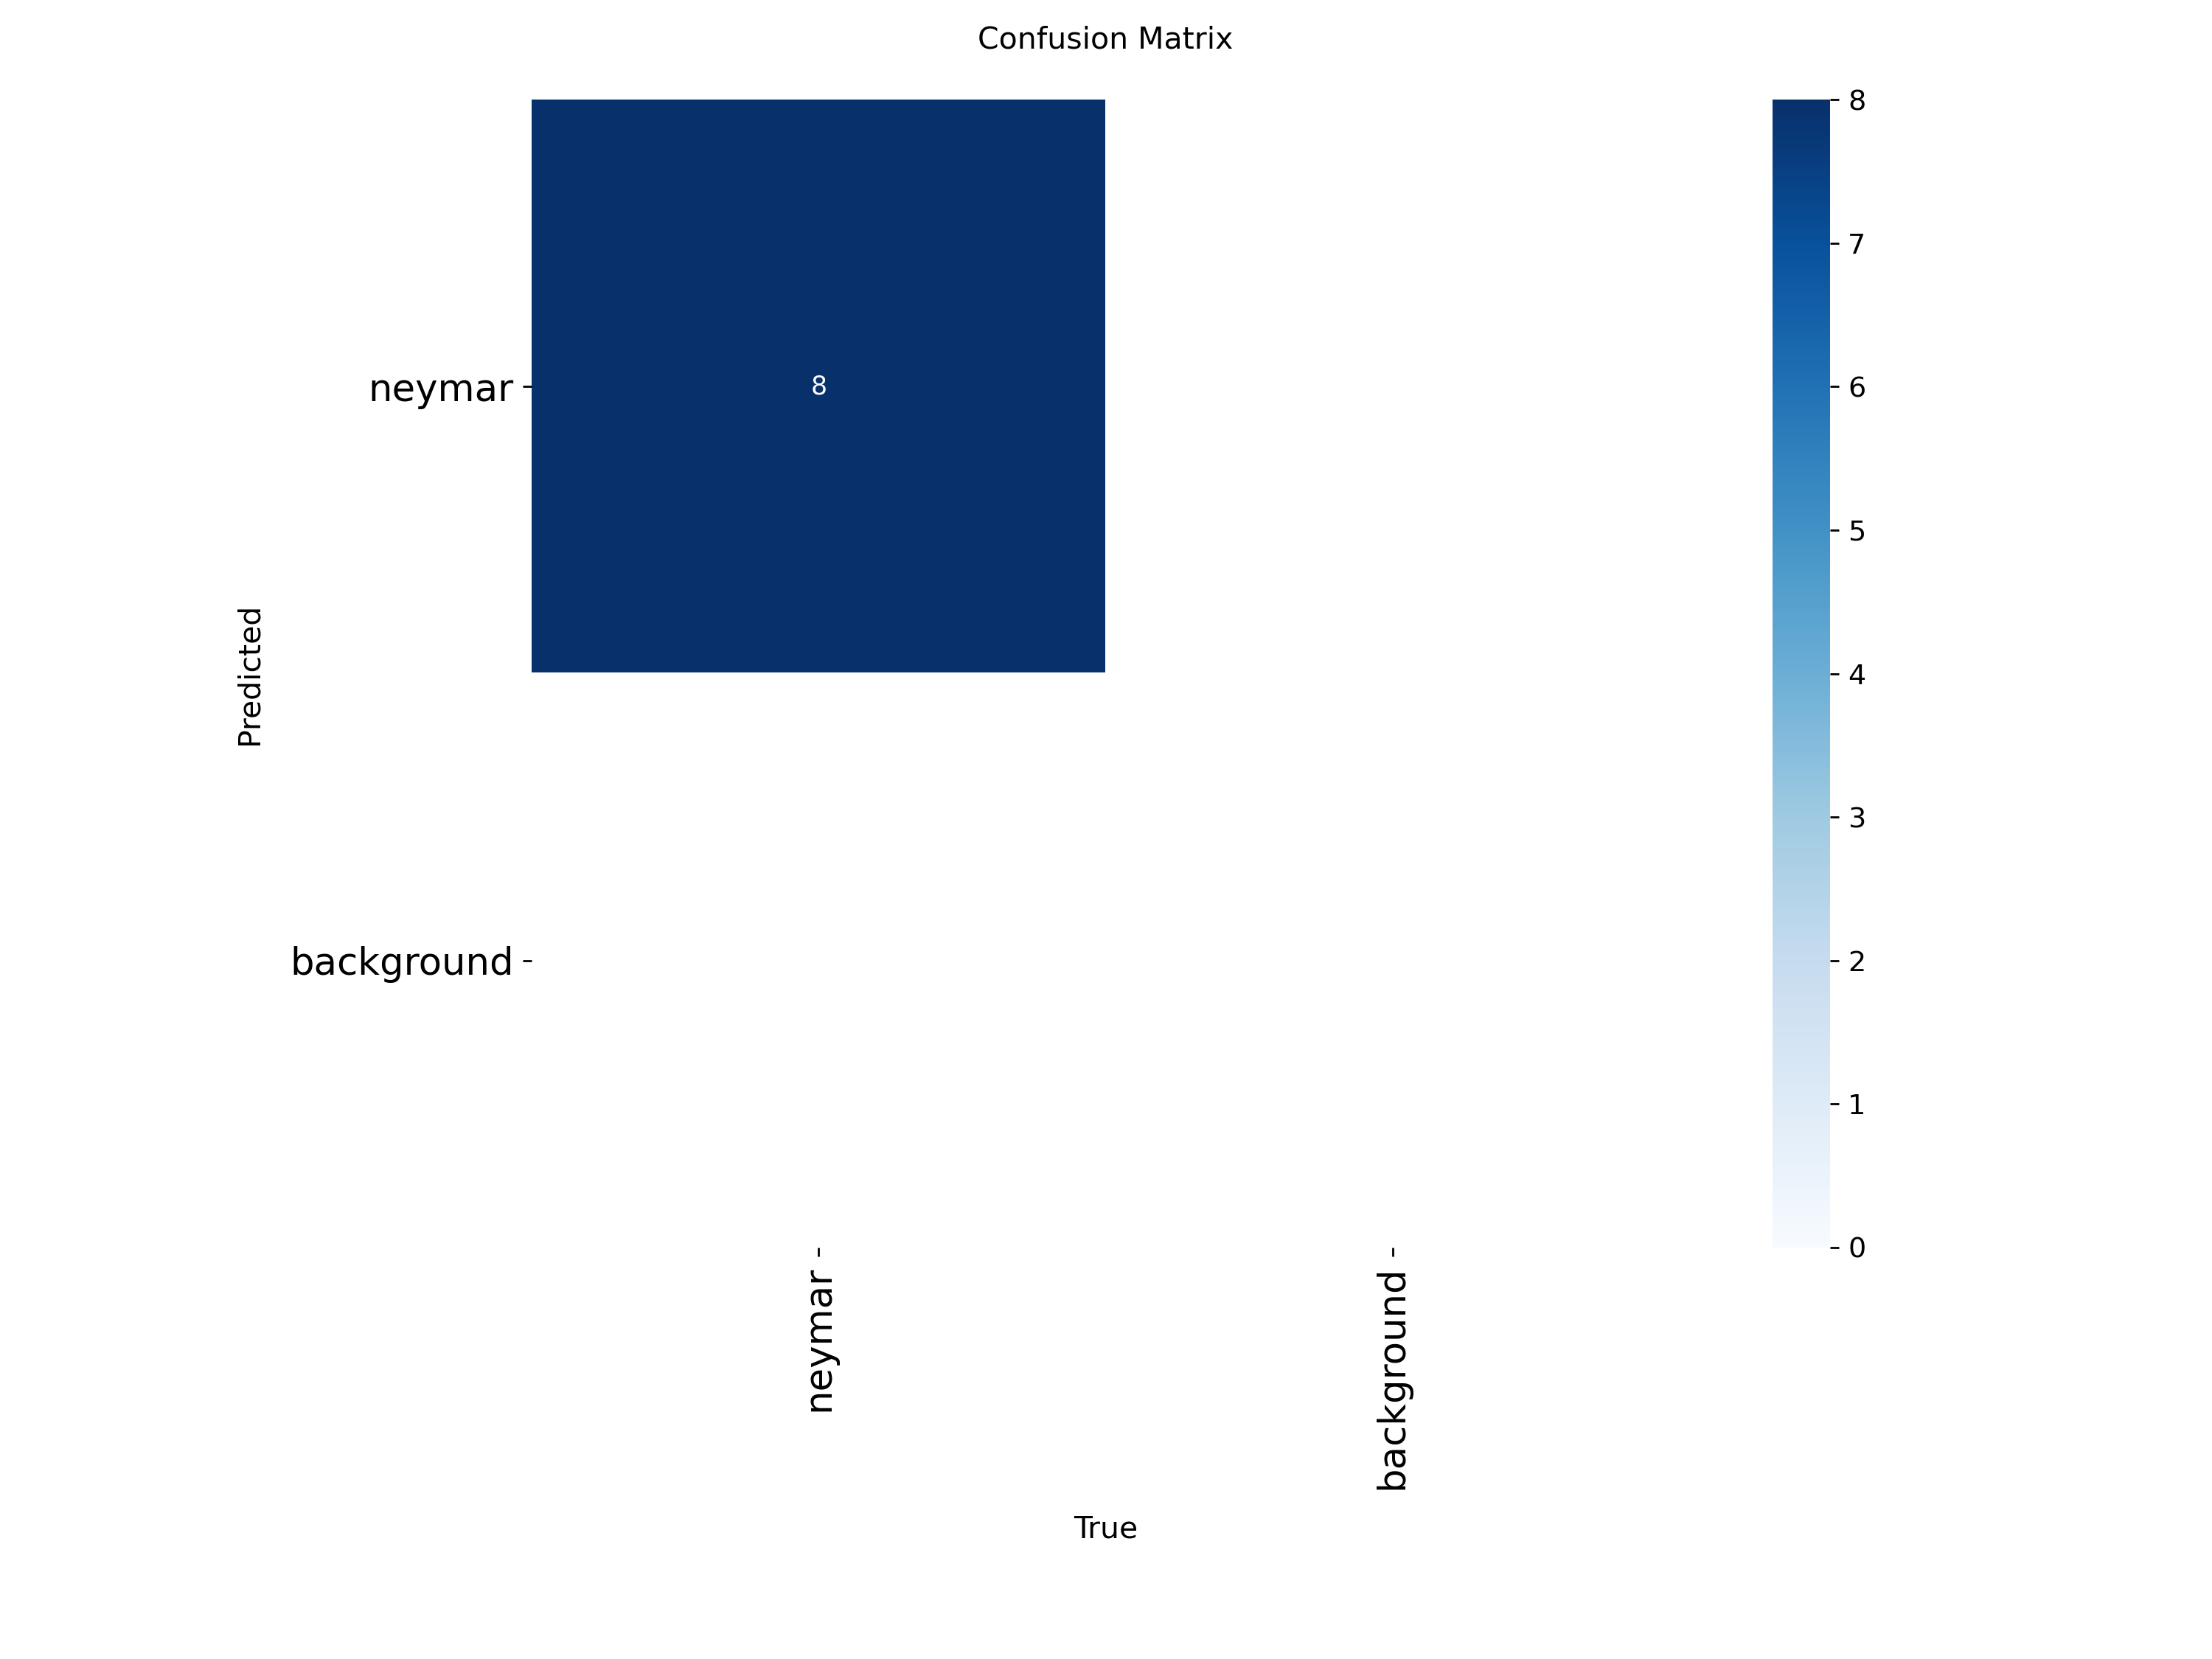

In [6]:
Image(filename=f'{results.save_dir}/confusion_matrix.png')

## 6. Validando em Imagens Reais (Inferência)
Vamos pegar algumas imagens da pasta de validação e ver como o modelo se saiu desenhando as caixas nelas.

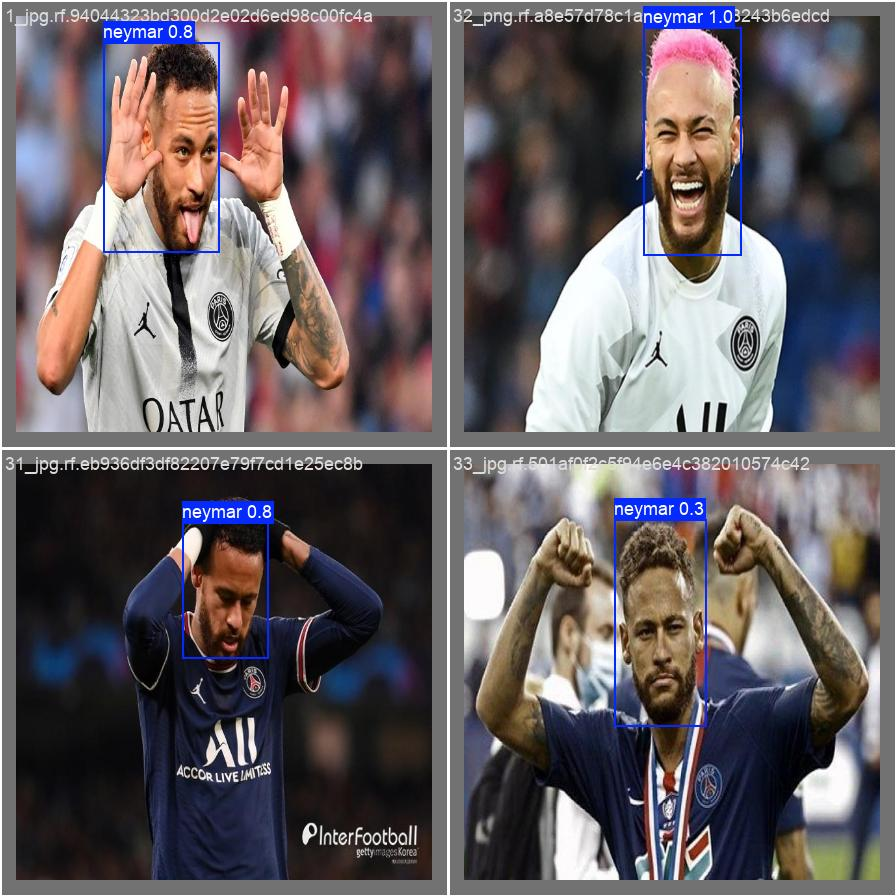

In [7]:
# O YOLO salva um lote de validação com as predições em 'val_batch0_pred.jpg'
Image(filename=f'{results.save_dir}/val_batch0_pred.jpg')

## 7. Exportar
Seu modelo treinado agora é o arquivo `best.pt`.
Você pode usá-lo em qualquer script com `model = YOLO('caminho/para/best.pt')`.